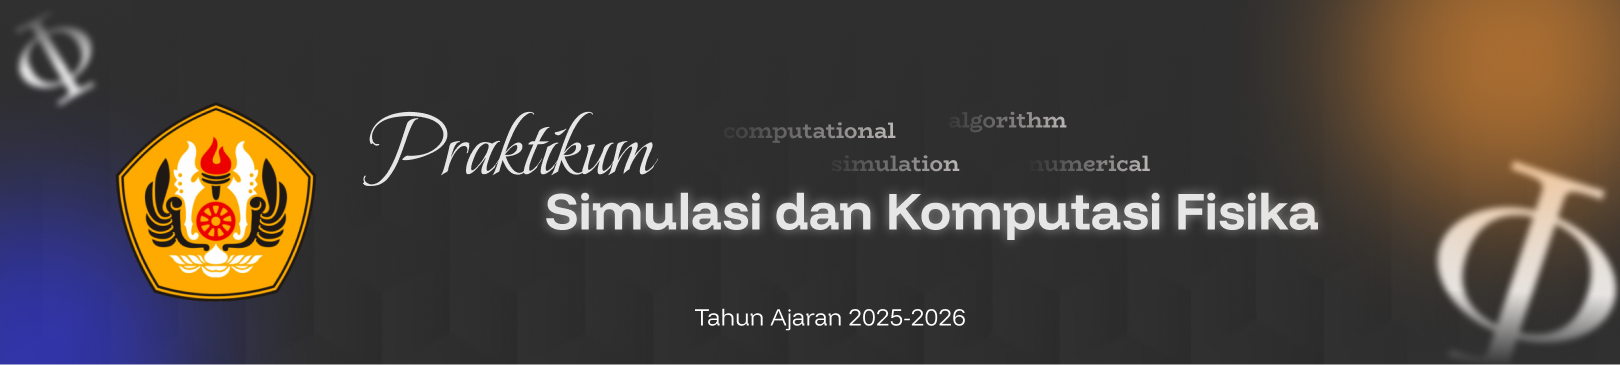

---

<div align="center">
   <h3></h3>
   <h1 text="bold"><b>M-2 - Stabilitas Numerik dan Resolusi Diskritisasi</b></h1>
</div>

<p align="center">Nama Kamu | NPM Kamu </p>
<p align="center">Mentor Praktikum : (Nama Mentor)</p>

---

## **I. Tujuan Praktikum**
Melalui modul ini diharapkan Mahasiswa mampu untuk:
1. Memahami apa yang dimaksud dengna stabilitas numerik dalam simulasi fisika
2. Menjelaskan pengaruh langkah waktu dan grid terhadap hasil simulasi.
3. Mengenali solusi numerik yang tidak stabil dan membedakannya dari perilaku fisika yang sebeneranya.
4. Menguji dan membandingkan hasil simulasi dengan parameter yang berbeda
5. Menentukan parameter numerik yang layak agar simulasi memberikan hasil yang masuk akal secara fisika.

---

## **2. Teori**

### 2.1. Apa itu Stabilitas Numerik?

Dalam fisika komputasi, solusi numerik diperoleh dengan mendiskritkan persamaan kontinu. Proses ini selalu menimbulkan kesalahan kecil.

**Stabilitas numerik** akan menjawab pertanyaan:

> *"Apakah kesalahan kecil ini akan tetap kecil, atau justru tumbuh dan merusak solusi?"*

- Apabila **stabil** → kesalahan akan tetap terkendali
- Apabila **tidak stabil** → kesalahan akan tumbuh secara eksponensial
- Apabila **tidak akurat tapi stabil** → solusi halus tapi salah secara kuantitatif

---

### 2.2. Diskritisasi Waktu

Untuk persamaan diferensial:

$$\frac{dy}{dt} = f(y, t)$$

Pendekatan numerik paling sederhana (metode **Forward Euler**):

$$y(n+1) = y(n) + f[y(n),\, t(n)]\,\Delta t$$

di mana:
- $\Delta t$ adalah langkah waktu
- indeks $n$ adalah waktu diskrit

Nilai $\Delta t$ sangat menentukan bagaimana solusi berperilaku:
- Apabila $\Delta t$ **terlalu besar** → solusi bisa tidak stabil
- Apabila $\Delta t$ **terlalu kecil** → solusi stabil tapi mahal komputasi (perhitungan akan lebih memakan banyak waktu)

---

### 2.3. Model Uji

#### 2.3.1. Contoh 1: Peluruhan Eksponensial

Gunakan persamaan sederhana:

$$\frac{dy}{dt} = -\lambda y$$

**Solusi analitik:**

$$y(t) = y(0)\,\exp(-\lambda t)$$

**Pendekatan numerik (Forward Euler):**

$$y(n+1) = y(n) - \lambda\, y(n)\,\Delta t$$

Persamaan ini secara fisika selalu stabil. Jika solusi numerik divergen, maka penyebabnya adalah **kesalahan numerik murni**.

---

Untuk menguji kualitas metode numerik, dilakukan **tiga pengujian**:

**a) Uji Konvergensi**

Menghitung error pada $t_\text{maks}$ terhadap solusi referensi dengan langkah waktu sangat kecil:

$$\text{error} = \left| y_\text{numerik}(t_\text{maks}) - y_\text{referensi}(t_\text{maks}) \right|$$

Dengan memperkecil $\Delta t$, error diharapkan mengecil secara proporsional terhadap $\Delta t$ (orde satu).

**b) Uji Konservasi Positivitas**

Memeriksa apakah solusi numerik menjadi negatif. Syarat agar $y_{n+1} \geq 0$:

$$1 - \lambda\Delta t \geq 0 \quad \Rightarrow \quad \Delta t \leq \frac{1}{\lambda}$$

Jika dilanggar, meskipun stabil, nilai negatif muncul dan **melanggar sifat fisis**.

**c) Uji Stabilitas**

Didasarkan pada faktor amplifikasi $|1 - \lambda\Delta t|$. Agar solusi tidak berosilasi dan divergen, harus dipenuhi:

$$|1 - \lambda\Delta t| \leq 1 \quad \Rightarrow \quad \Delta t \leq \frac{2}{\lambda}$$

Bila $\Delta t$ melebihi batas ini, solusi numerik akan **meledak** (divergen).

---

**Implementasi Python – Kode 2.1:**

```python
import numpy as np
import matplotlib.pyplot as plt

# Parameter
l, y0, T = 1.0, 1.0, 5.0
dt_list = np.array([0.05, 0.1, 0.5, 1.0, 2.0])

# Solusi referensi (analitik Euler dengan dt kecil)
dt_ref = 0.001
N_ref = int(round(T / dt_ref))
t_ref = np.linspace(0, T, N_ref + 1)
y_ref = y0 * (1 - l * dt_ref) ** np.arange(N_ref + 1)
y_ref_end = y_ref[-1]

# Plot
errors = []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for dt in dt_list:
    N = int(round(T / dt))
    t = np.linspace(0, T, N + 1)
    y = y0 * (1 - l * dt) ** np.arange(N + 1)  # closed-form Euler iterate
    ax1.plot(t, y, 'o-', label=f'dt={dt}')
    errors.append(abs(y[-1] - y_ref_end))

    if np.any(y < 0):
        print(f'Peringatan: dt={dt} menghasilkan nilai negatif')
    if np.max(np.abs(y)) > 1e3:
        print(f'Peringatan: dt={dt} divergen')

# Referensi & konfigurasi plot
ax1.plot(t_ref, y_ref, 'k--', label=f'ref dt={dt_ref}', lw=1)
ax1.set(xlabel='t', ylabel='y', title='Solusi Numerik')
ax1.legend()
ax1.grid(True)

errors = np.array(errors)
ax2.loglog(dt_list, errors, 'bo-', label='Error')
ax2.loglog(dt_list, errors[0] * (dt_list / dt_list[0]), 'r--', label='slope 1')
ax2.set(xlabel='dt', ylabel='Error', title='Konvergensi')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print('\nHasil uji konvergensi:')
for dt, err in zip(dt_list, errors):
    print(f'dt={dt:.3f}, error={err:.3e}')
```


![gambar2.1.png]( 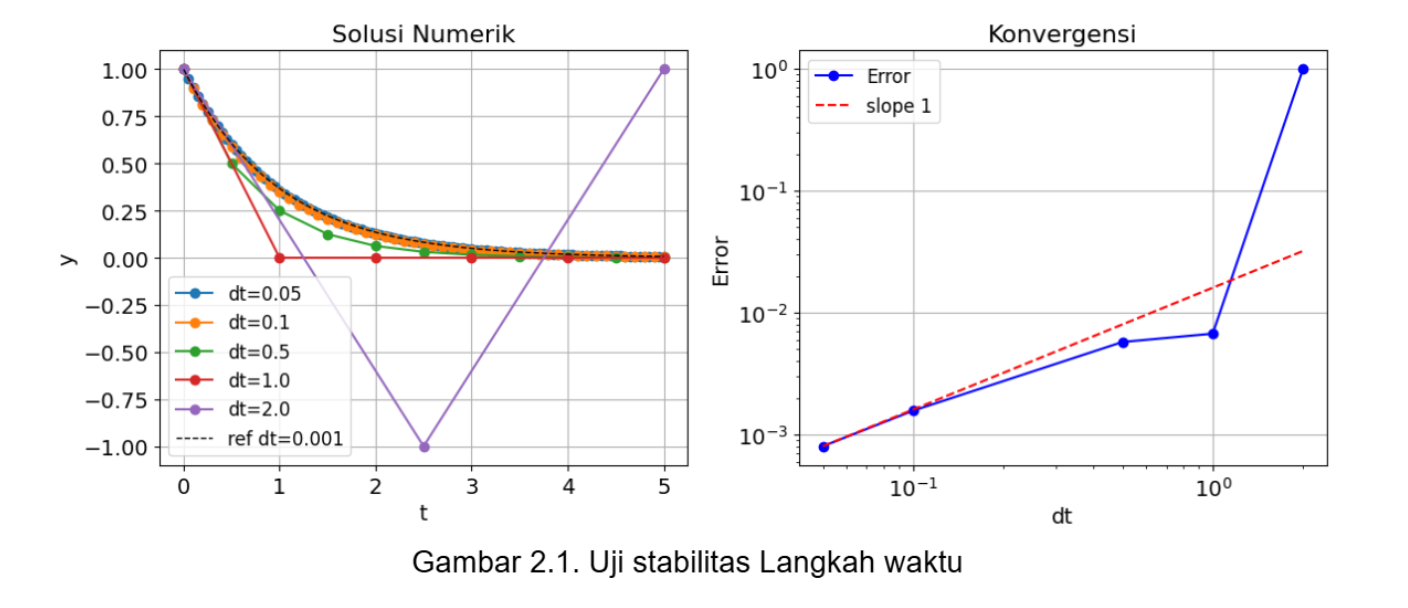 )

**Hasil simulasi** menunjukkan bahwa semakin kecil $\Delta t$, error semakin kecil (konvergen). Namun $\Delta t$ yang terlalu besar (misalnya $> 2/\lambda$) dapat menyebabkan solusi divergen. Di antara rentang stabil, ada pula $\Delta t$ yang meskipun tidak divergen, tetap menghasilkan nilai negatif pada langkah awal sehingga tidak memenuhi syarat konservasi. Dengan demikian, pemilihan $\Delta t$ harus mempertimbangkan tidak hanya ketelitian, tetapi juga **batasan stabilitas** dan **konservasi sifat fisis** sistem. Di sisi lain, $\Delta t$ yang sangat kecil akan meningkatkan jumlah langkah waktu dan waktu komputasi, sehingga diperlukan **keseimbangan antara akurasi dan efisiensi**.

---

#### 2.3.2. Contoh 2: Stabilitas pada Sistem Osilator Harmonik

Persamaan model osilator harmonik:

$$\frac{d^2x}{dt^2} = -\omega^2 x$$

Ubah menjadi **sistem orde-1**:

$$\frac{dx}{dt} = v$$

$$\frac{dv}{dt} = -\omega^2 x$$

**Pendekatan numerik (Forward Euler):**

$$x(n+1) = x(n) + v(n)\,\Delta t$$

$$v(n+1) = v(n) - \omega^2\, x(n)\,\Delta t$$


![gambar2.2.png]( 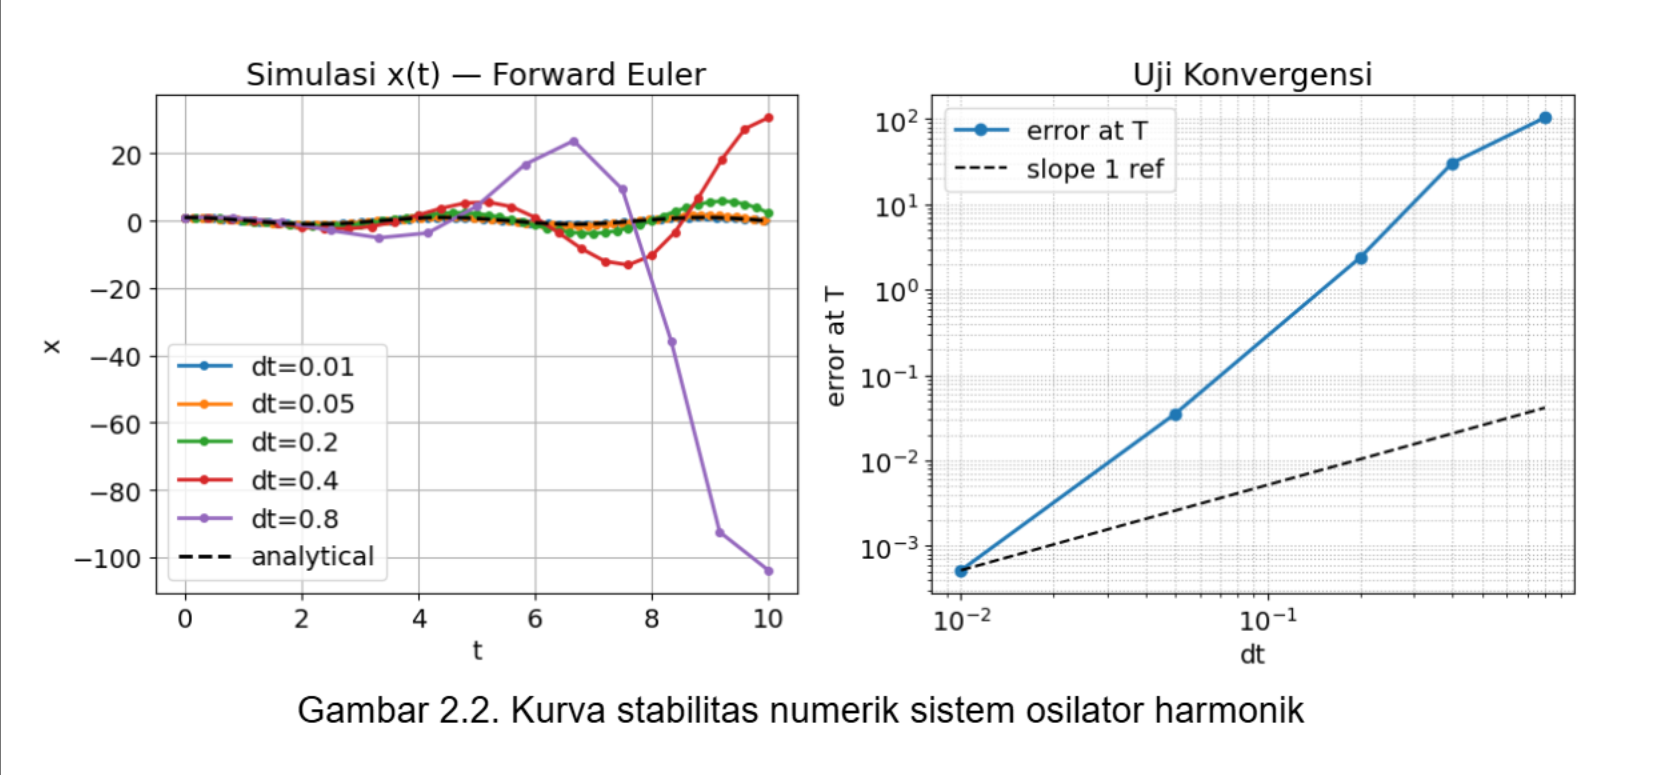 )

Dengan kondisi awal $x(0) = 1.0$, $v(0) = 0$, $\omega = 2.0$, dan variasi $\Delta t = 0.01,\; 0.05,\; 0.2,\; 0.4,\; 0.8$ akan terlihat perbedaan kestabilan numerik.

Secara fisika, nilai amplitudo seharusnya **tetap** terhadap waktu. Namun secara numerik, amplitudo dapat:
- **Tumbuh** → sistem tidak stabil (*divergen*)
- **Menyusut** → *numerical damping* (redaman numerik)

Pemilihan $\Delta t$ yang terlalu besar akan menyebabkan sistem semakin tidak stabil.

> **Catatan penting:** Dalam fisika komputasi, komputer tidak pernah *"berbohong"*, tetapi ia bisa *"menyesatkan"* jika kita tidak memahami batasannya.

---

## **3. Tugas Praktikum**

### Petunjuk Umum

1. Gunakan bahasa pemrograman **Python**.
2. Setiap bagian harus disertai **(1) grafik hasil simulasi** dan **(2) analisis singkat** (narasi, bukan hanya angka).
3. Jawaban tidak dinilai dari benar–salah angka, tetapi dari **(1) ketepatan interpretasi**, **(2) konsistensi fisika–numerik**, **(3) kualitas visualisasi**.

---

### [1] – Peluruhan Eksponensial Terkopel

Terapkan **Kode 2.1** untuk menguji stabilitas numerik pada persamaan **peluruhan eksponensial terkopel** (dari Modul-1, Tugas Akhir Nomor 3). Tetapkan nilai $y(0) = 1$ dan $\lambda = 1$. Lakukan simulasi untuk minimal **5 nilai $\Delta t$** berbeda (dua stabil, satu batas stabil, dan dua tidak stabil). Bandingkan hasil numerik dengan solusi analitik.

**a)** Apa yang berbeda dari grafik error-nya jika dibandingkan terhadap hasil dari Kode 2.1?

**b)** Pada nilai $\Delta t$ berapa solusi mulai menyimpang, dan apakah penyimpangan tersebut bersifat fisis?

**c)** Apa hubungan $\Delta t$ dengan skala waktu sistem?

**d)** Apakah solusi numerik "rusak" sejak awal atau secara bertahap?

---

### [2] – Sistem Osilator Harmonik

Ubah persamaan osilator harmonik pada Contoh 2 menjadi sistem orde-1 dan terapkan pendekatan numeriknya. Gunakan $x(0) = 1.0$, $v(0) = 0.0$, $\omega = 2.0$. Simulasikan untuk minimal **5 nilai $\Delta t$** berbeda (dua stabil, satu batas stabil, dan dua tidak stabil), kemudian amati:

**a)** Perubahan amplitudo dan munculnya redaman numerik (*numerical damping*).

**b)** Bagaimana grafik konvergensinya?

---

### [3] – Pertanyaan Naratif

Jawab pertanyaan berikut secara naratif:

**a)** Apa perbedaan antara **solusi tidak stabil** dan **solusi tidak akurat**?

**b)** Mengapa simulasi yang terlihat halus belum tentu benar secara fisika?

**c)** Jika Anda melakukan simulasi riset, uji apa yang wajib dilakukan terlebih dahulu?

**d)** Bagaimana Modul-2 ini mengubah cara Anda memandang hasil simulasi?

---
> Dalam fisika komputasi, komputer tidak pernah *"berbohong"*,
> tetapi ia bisa *"menyesatkan"* jika kita tidak memahami batasannya.
---

## **IV. Percobaan Praktikum**

### **4.1 Percobaan 1**

### Analisis Percobaan 1

---

### **4.2 Percobaan 2**

### Analisis Percobaan 2

### **4.3 Percobaan 3**

### Analisis Percobaan 3

---

## **Daftar Pustaka**

Santrock, J. W. (2018). *A topical approach to life-span development* (9th ed.). McGraw-Hill Education.